In [1]:
import numpy as np
import rebound
import sys
sys.path.insert(0,'../model')
from matplotlib.collections import PatchCollection
import mega
import matplotlib.pyplot as plt
from multiprocessing import Pool
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
cm = plt.colormaps['hot_r']

In [2]:
print("Available constellations:")
for key in mega.constellations_all:
    print(key)

Available constellations:
Stampede
Sunrise
SXODC
Starlink
OneWeb
StarNet/GW
Kuiper


In [28]:
worker_sims = None
constellation = None
plot_type = None
def init_worker(_constellation, _plot_type):
    global worker_sims, constellation, plot_type
    constellation = _constellation
    plot_type = _plot_type
    worker_sims = {constellation: rebound.Simulation("mega_"+constellation+".bin")}
def getNum(l):    
    Ndate = 8
    latitude=-90+180*l/(Nlat-1)
    row = np.full(Ndate,np.nan)
    for d in range(Ndate):
        month=(d/Ndate+0.5)*12 -79/365*12
        lon = mega.length_of_night(month,latitude)
        if plot_type == "midnight":
            if (lon>0.0):
                xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=0, area=800, elevation_cut=10)
                row[d] = np.sum(mag < 5.0)
        elif plot_type == "sunset":
            if (lon>0.0) and (lon<24.0):
                xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=-lon/2., area=800, elevation_cut=10)
                row[d] = np.sum(mag < 5.0)
    return row

In [29]:
Nlat = 8
with Pool(processes=80, initializer=init_worker, initargs=("SXODC","sunset",)) as p:
    data = np.array(p.map(getNum, range(Nlat)))

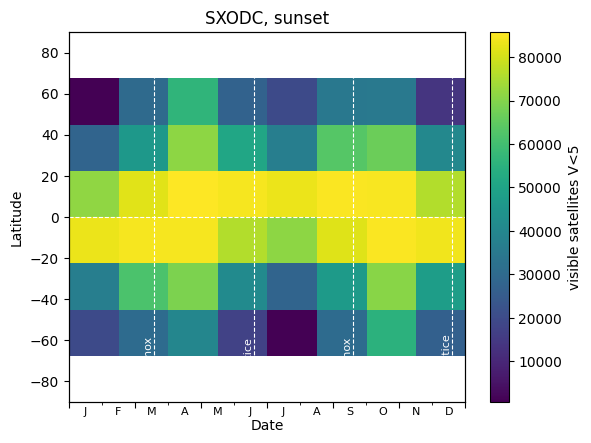

In [40]:
fig, ax = plt.subplots()
a
# Plot data
cb = ax.imshow(data, extent=(0, 12, -90,90), interpolation="nearest", aspect="auto", origin="lower")
fig.colorbar(cb,label="visible satellites V<5")

# Labels
ax.set_xlabel("Date",labelpad=7)
ax.set_ylabel("Latitude")
ax.set_title("SXODC, sunset")

# Axes
months = ["J","F","M","A","M","J","J","A","S","O","N","D"]
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.xaxis.set_ticks_position("bottom")
ax2.tick_params(axis="x", which="major", length=0, labelbottom = False)
ax2.tick_params(axis="x", which="minor", length=0, labelsize=8)
ax2.set_xticks(np.arange(0.5,12.5,1), labels=months, minor=True)
ax.tick_params(axis="x",which="major",labelbottom = False,length=4)
ax.xaxis.set_ticks(np.arange(0,13,1),minor=True)
ax.tick_params(axis="x",which="major",length=4)

# Grid
ax.axhline(0, color="white", linestyle="--", linewidth=0.8)
astlabels = {"S Equinox":79/365*12, "S Solstice":(79/365+0.25)*12, "F Equinox":(79/365+0.5)*12, "W Solstice":(79/365+0.75)*12}
for label in astlabels:
    ax.axvline(astlabels[label], color="white", linestyle="--", linewidth=0.8)
    ax.text(x=astlabels[label], y=-85, s=label, rotation=90, verticalalignment="bottom", horizontalalignment="right", color="white", size=8)

